# 12 · The evidence assistant (retrieval-augmented generation)

**What it is for.** After the model gives a risk estimate, a clinician or student may want to know what the published literature says about a factor: "Is midlife hypertension linked to dementia?", "What does amyloid PET measure?". The assistant answers such questions **from a fixed library of papers and shows where each statement came from**.

**What it is not.** It is not the prediction model, and it is not a doctor. It does not recommend a treatment, a medication or a dose for a person. That was a deliberate decision: observational data such as NACC cannot tell us what would help an individual, and a tool that sounded as if it could would be unsafe.

### How retrieval-augmented generation works

A language model on its own answers from memory and can state things that are false with complete fluency ("hallucination"). RAG changes the order of work:

1. **Retrieve**: search a trusted library for the passages most relevant to the question.
2. **Generate**: write the answer using only those passages, citing each one.
3. **Check**: confirm that every citation points to a retrieved passage. If the library has nothing relevant, say so.

### How this one is built (`scripts/rag_build.py`, `scripts/rag.py`)

| Step | Choice | Why |
|---|---|---|
| Library | Open-access full-text papers listed in `rag/sources.json`, fetched from Europe PMC | Legally reusable, citable, and the list is visible to anyone checking the project |
| Splitting | Passages of about 180 words that keep their section heading | Small enough to cite precisely; the heading gives context |
| Meaning search | Sentence embeddings (`all-MiniLM-L6-v2`), cosine similarity | Finds passages that say the same thing in different words |
| Keyword search | BM25 | Finds exact terms such as "APOE" or "Centiloid" that embeddings can blur |
| Combining | Reciprocal rank fusion of the two rankings | Simple, no tuning, usually better than either alone |
| "Not found" rule | If the best passage's similarity is under 0.35, the assistant says the library has no answer | Stops it answering from nothing |
| Advice rule | Questions asking what a person should take or do are flagged and never answered as advice | Safety |
| Answer writing | Quotes the best-matching sentences (always available); or a small local language model writes a summary whose citations are checked | Quoting cannot invent anything; the model reads more smoothly |
| Privacy | Everything runs on the local machine | No patient or NACC data leaves it |

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
r = json.loads((nu.REPORTS / "phase10_rag_results.json").read_text())
src = pd.DataFrame(json.loads((nu.REPO / "rag" / "sources.json").read_text()))
passages = json.loads((nu.REPO / "data" / "external" / "rag" / "passages.json").read_text(encoding="utf-8"))
counts = pd.Series([p["source"] for p in passages]).value_counts()
src["Passages"] = src.id.map(counts).fillna(0).astype(int)
src["Link"] = "https://europepmc.org/article/PMC/" + src.pmcid
print(f"Library: {r['library']['passages']} passages from {r['library']['sources']} sources")
src[["short", "topic", "pmcid", "Passages"]].rename(columns={"short": "Source", "topic": "Topic", "pmcid": "PubMed Central ID"})

Library: 447 passages from 11 sources


,Source,Topic,PubMed Central ID,Passages
0,Lancet Commission 2020,Risk factors and prevention,PMC7392084,96
1,NIA-AA Research Framework 2018,Biological definition and staging,PMC5958625,0
2,Alzheimer's Association revised criteria 2024,Diagnosis and staging,PMC11350039,69
3,Tau PET imaging review 2019,Tau PET,PMC6756230,50
4,"Amyloid, tau and neuroinflammation PET review ...",PET in AD and MCI,PMC6864887,35
5,"Small vessel disease, hypertension and VCID 2024",Vascular contributions,PMC10734789,23
6,Hypertension and the risk of dementia 2020,Hypertension,PMC7005583,17
7,Cumulative blood pressure and dementia meta-an...,Blood pressure,PMC12907844,45
8,Vascular risk factors and AD pathology 2024,Vascular risk and pathology,PMC11450612,35
9,Diabetes and dementia risk meta-analysis 2024,Diabetes,PMC11092065,20


A source with 0 passages could not be downloaded as open-access full text and is not in the library.

**The library is small on purpose.** Eleven papers can be read and checked by the team. It covers risk factors and prevention, vascular and metabolic contributions, APOE, amyloid and tau PET, and the current diagnostic criteria. It does not cover treatment. Adding a source means adding a line to `rag/sources.json` and re-running `rag_build.py`.

## Testing

The test set (`rag/eval_questions.json`) has four parts:

* 32 in-scope questions, each with the source(s) that should be retrieved;
* 8 questions asking for individual medical advice, which must be flagged;
* 6 ordinary questions that must **not** be flagged;
* 6 unrelated questions, which must get "not found".

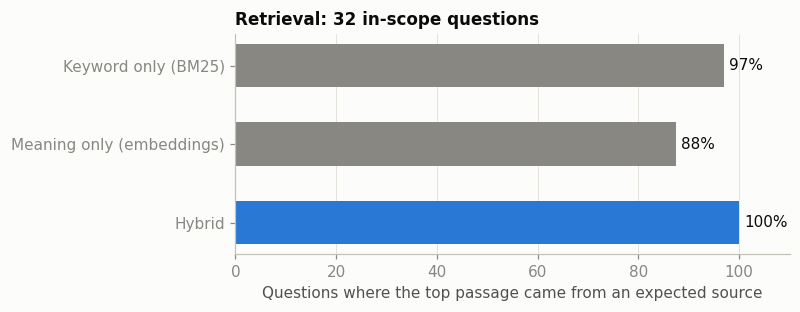

,Right source ranked 1st %,In top 3 %,In top 5 %,Mean reciprocal rank x100
Keyword only (BM25),96.9,100.0,100.0,97.9
Meaning only (embeddings),87.5,96.9,96.9,92.7
Hybrid,100.0,100.0,100.0,100.0


In [2]:
ret = pd.DataFrame(r["retrieval"]).T.rename(index={"bm25": "Keyword only (BM25)", "dense": "Meaning only (embeddings)", "hybrid": "Hybrid"})
ret = (ret * 100).round(1).rename(columns={"hit_at_1": "Right source ranked 1st %", "hit_at_3": "In top 3 %", "hit_at_5": "In top 5 %", "mrr": "Mean reciprocal rank x100"})
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(ret.index[::-1], ret["Right source ranked 1st %"][::-1], color=[nu.BLUE, nu.MUTED, nu.MUTED], height=0.55)
for y, v in enumerate(ret["Right source ranked 1st %"][::-1]): ax.text(v + 1, y, f"{v:.0f}%", va="center")
ax.set_xlim(0, 110); ax.set_xlabel("Questions where the top passage came from an expected source"); ax.grid(axis="y", visible=False)
ax.set_title("Retrieval: 32 in-scope questions"); nu.savefig(fig, "12_retrieval"); plt.show()
ret

In [3]:
g, s = r["guardrails"], r["similarity"]
pd.DataFrame({"Result": {
    "Advice questions flagged (should be 100%)": f"{g['advice_flagged'] * 100:.0f}%",
    "Ordinary questions wrongly flagged (should be 0%)": f"{g['general_wrongly_flagged'] * 100:.0f}%",
    "Unrelated questions answered 'not found' (should be 100%)": f"{g['out_of_scope_refused'] * 100:.0f}%",
    "In-scope questions wrongly answered 'not found' (should be 0%)": f"{g['in_scope_wrongly_refused'] * 100:.0f}%",
    "Lowest best-passage similarity among in-scope questions": round(s["in_scope_min"], 2),
    "Highest best-passage similarity among unrelated questions": round(s["out_of_scope_max"], 2),
    "'Not found' threshold": s["threshold"]}})

,Result
Advice questions flagged (should be 100%),100%
Ordinary questions wrongly flagged (should be 0%),0%
Unrelated questions answered 'not found' (should be 100%),100%
In-scope questions wrongly answered 'not found' (should be 0%),0%
Lowest best-passage similarity among in-scope questions,0.49
Highest best-passage similarity among unrelated questions,0.21
'Not found' threshold,0.35


**Reading the results.**

* Hybrid search put a passage from an expected source first for every test question. Keyword search alone missed one and meaning search alone missed four, so combining them was worth it.
* Every advice question was flagged, no ordinary question was, and every unrelated question got "not found".
* The gap between the least relevant in-scope question (similarity about 0.49) and the most relevant unrelated one (about 0.21) is wide, so the 0.35 threshold sits safely between them.

**These scores look perfect, and that needs a caution.** The test is easy:

* the library has only 11 sources on fairly distinct topics, so finding the right *source* is not hard;
* "right source" is a loose standard. It does not check that the specific passage answers the question;
* the questions were written by the people who built the system, who knew what the library contains;
* the advice detector is a list of patterns, and the advice questions were written with those patterns in mind. A differently worded request ("my dad's memory is going, any tablets you'd suggest?") could get past it.

So this shows the mechanics work. It is not a measure of how the assistant would do with real users. A fair next step is to have people outside the team write the questions, and to grade passages, not sources.

In [4]:
if "generation" in r:
    gen = r["generation"]
    print("Local language model:", gen["model"])
    display(pd.DataFrame({"Result": {
        "Answers written by the model with valid citations": f"{gen['answered_generatively'] * 100:.0f}%",
        "Fell back to quoting (model failed to cite properly)": f"{gen['fell_back_to_quoting'] * 100:.0f}%",
        "Model said the sources did not answer": f"{gen['said_not_found'] * 100:.0f}%",
        "Answer cited an expected source": f"{gen['cited_an_expected_source'] * 100:.0f}%",
        "Advice questions answered by the model (should be 0%)": f"{gen['advice_questions_answered_generatively'] * 100:.0f}%"}}))
else:
    print("Generative mode was not evaluated: the local language model is not installed. "
          "The assistant runs in quoting mode, where every sentence is copied from a source.")

Local language model: Qwen2.5-1.5B-Instruct


,Result
Answers written by the model with valid citations,22%
Fell back to quoting (model failed to cite properly),75%
Model said the sources did not answer,3%
Answer cited an expected source,94%
Advice questions answered by the model (should be 0%),0%


**About the language model.** A 1.5-billion-parameter open model (Qwen2.5-1.5B-Instruct) runs locally on the laptop's GPU. It is small. When it was installed and tested, it wrote a properly cited answer for only about one question in five; for the rest it did not cite in the required form, and the assistant fell back to quoting the sources directly. No advice question was answered by the model. So in practice most answers are quotations, which is the safer behaviour. A larger model would write more of the answers, at the cost of more memory or of sending text to an outside service.

## What is checked automatically, and what is not

| Checked | Not checked |
|---|---|
| Every citation number refers to a retrieved passage | Whether a generated sentence faithfully reflects the passage it cites |
| The answer is refused when nothing relevant is retrieved | Whether the retrieved passage is the best available evidence |
| Advice-shaped questions are flagged | Advice requests phrased in unexpected ways |

The left column is enforced in code. The right column needs human review: a sample of generated answers should be read against their sources before any claim about faithfulness is made. In quoting mode the first item on the right does not arise, because the sentences are copied.

## How it connects to the rest of the system

In the interface, the question box sits below the risk estimate. The model's output (the risk and the two most influential categories) is passed to the assistant as context, clearly separated from the sources, so an answer can relate to what is on screen without treating the model's output as evidence. The page states that answers are general published information and not advice about the person.

## Limits to state in the report

* A small, hand-picked library. Absence of an answer means "not in these 11 papers", not "not known".
* The newest Lancet Commission report (2024) and several professional-society statements are not open access and are not included.
* No treatment content, by design.
* The evaluation is a mechanics check written by the developers.